In [2]:
import pandas as pd
import numpy as np
data =pd.read_csv('raw_data_exact.csv')
data.head()

,X1,X2,label
0,1.5,8.0,0
1,2.0,9.0,0
2,2.0,6.0,0
3,3.0,8.0,0
4,3.0,3.0,0


In [3]:
x=data.drop(['label'],axis=1)
y=data.loc[:,'label']

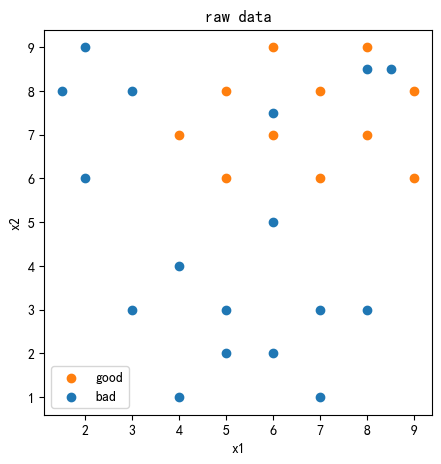

In [4]:
%matplotlib inline
from matplotlib import pyplot as plt
fig1=plt.figure(figsize=(5,5))
bad=plt.scatter(x.loc[:,'X1'][y==0],x.loc[:,'X2'][y==0])
good=plt.scatter(x.loc[:,'X1'][y==1],x.loc[:,'X2'][y==1])
plt.legend((good,bad),('good','bad'))
plt.title('raw data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [5]:
from sklearn.covariance import EllipticEnvelope
ad_model=EllipticEnvelope(contamination=0.1)
ad_model.fit(x[y==0])
y_predict_bad=ad_model.predict(x[y==0])
print(y_predict_bad)

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1  1]


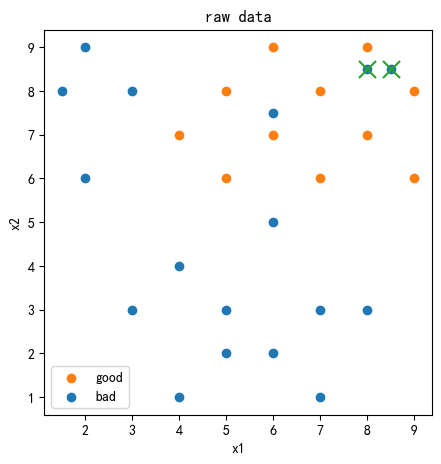

In [6]:
fig2=plt.figure(figsize=(5,5))
bad=plt.scatter(x.loc[:,'X1'][y==0],x.loc[:,'X2'][y==0])
good=plt.scatter(x.loc[:,'X1'][y==1],x.loc[:,'X2'][y==1])
plt.scatter(x.loc[:,'X1'][y==0][y_predict_bad==-1],x.loc[:,'X2'][y==0][y_predict_bad==-1],marker='x',s=150)
plt.legend((good,bad),('good','bad'))
plt.title('raw data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [10]:
bad_rows_indices = data[y == 0].index  # 提取y==0的所有行的索引
indices_to_drop = bad_rows_indices[y_predict_bad == -1]  # 只保留异常的行索引
data_1 = data.drop(indices_to_drop, axis=0)  # axis=0表示按行删除

data_1.to_csv("data_class_processed.csv", index=False)

In [13]:
data =pd.read_csv('data_class_processed.csv')
x=data.drop(['label'],axis=1)
y=data.loc[:,'label']

[0.51273257 0.48726743]


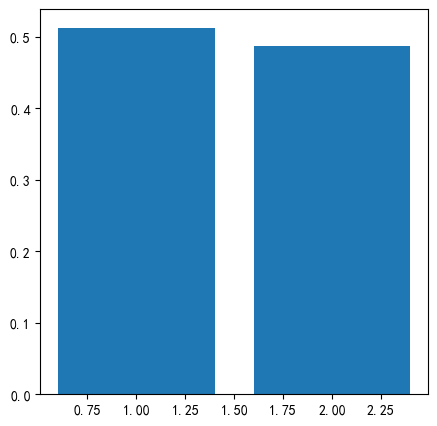

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
x_norm=StandardScaler().fit_transform(x)
pca=PCA(n_components=2)
x_reduced=pca.fit_transform(x_norm)
var_ratio=pca.explained_variance_ratio_
print(var_ratio)

fig3=plt.figure(figsize=(5,5))
plt.bar([1,2],var_ratio)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4)
print(x_train.shape,x_test.shape,x.shape)

(15, 2) (11, 2) (26, 2)


In [21]:
from sklearn.neighbors import KNeighborsClassifier
knn_10=KNeighborsClassifier(n_neighbors=10)
knn_10.fit(x_train,y_train)
y_train_predict=knn_10.predict(x_train)
y_test_predict=knn_10.predict(x_test)

from sklearn.metrics import accuracy_score
accuracy_train=accuracy_score(y_train,y_train_predict)
accuracy_test=accuracy_score(y_test,y_test_predict)
print('trianing accuracy:',accuracy_train) 
print('testing accuracy:',accuracy_test)

trianing accuracy: 0.8666666666666667
testing accuracy: 0.7272727272727273


In [23]:
xx,yy=np.meshgrid(np.arange(0,10,0.05),np.arange(0,10,0.05))
x_range=np.c_[xx.ravel(),yy.ravel()]

D:\Anaconda3\envs\imooc_ai\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


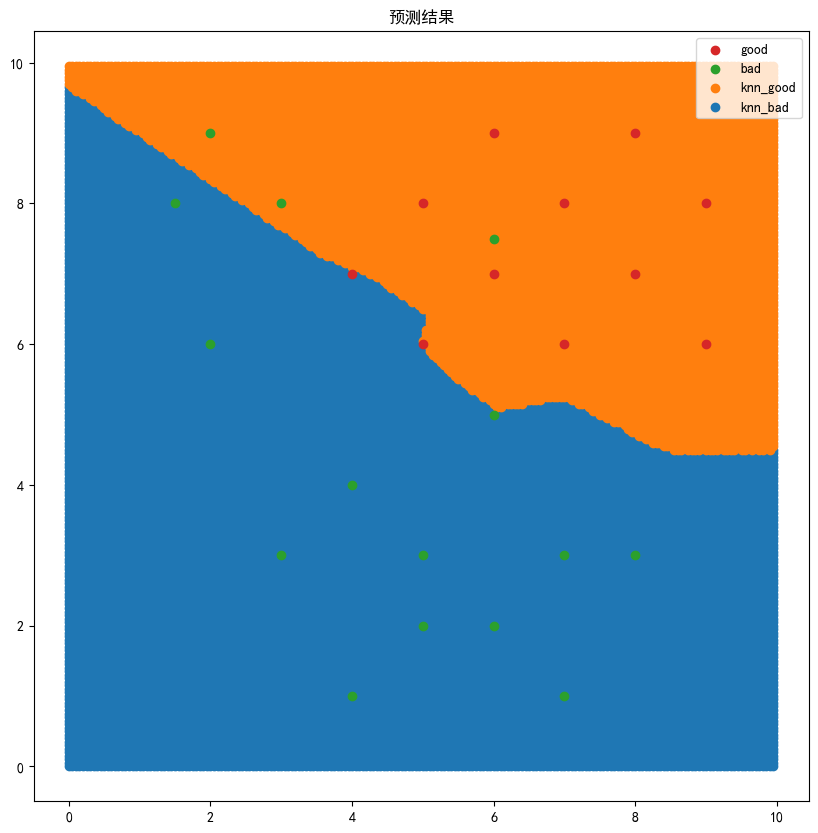

In [26]:
y_range_predict=knn_10.predict(x_range)

fig4=plt.figure(figsize=(10,10))
knn_bad=plt.scatter(x_range[:,0][y_range_predict==0],x_range[:,1][y_range_predict==0])
knn_good=plt.scatter(x_range[:,0][y_range_predict==1],x_range[:,1][y_range_predict==1])

bad=plt.scatter(x.loc[:,'X1'][y==0],x.loc[:,'X2'][y==0])
good=plt.scatter(x.loc[:,'X1'][y==1],x.loc[:,'X2'][y==1])
plt.legend((good,bad,knn_good,knn_bad),('good','bad','knn_good','knn_bad'))
plt.title('预测结果')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [28]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_test_predict)
print(cm)

[[5 2]
 [1 3]]


In [29]:
TP=cm[1,1] 
TN=cm[0,0]
FP=cm[0,1] 
FN=cm[1,0]
print(TP,TN,FP,FN)

3 5 2 1


In [31]:
accuracy=(TP+TN)/(TP+TN+FP+FN)
recall=TP/(TP+FN)
specificity=TN/(TN+FP)
precision=TP/(TP+FP)
f1=2*precision*recall/(precision+recall)
print(accuracy,recall,specificity,precision,f1)

0.7272727272727273 0.75 0.7142857142857143 0.6 0.6666666666666665


In [43]:
n=[i for i in range(1,16)]
accuracy_train=[]
accuracy_test=[]
for i in n:
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_train_predict=knn.predict(x_train)
    y_test_predict=knn.predict(x_test)
    accuracy_train_i=accuracy_score(y_train,y_train_predict)
    accuracy_test_i=accuracy_score(y_test,y_test_predict)
    accuracy_train.append(accuracy_train_i)
    accuracy_test.append(accuracy_test_i)
print(accuracy_train,accuracy_test)

[1.0, 0.9333333333333333, 0.9333333333333333, 1.0, 0.8666666666666667, 0.9333333333333333, 0.8666666666666667, 0.9333333333333333, 0.8666666666666667, 0.8666666666666667, 0.9333333333333333, 0.8666666666666667, 0.6, 0.5333333333333333, 0.5333333333333333] [0.7272727272727273, 0.7272727272727273, 0.9090909090909091, 0.9090909090909091, 0.8181818181818182, 0.7272727272727273, 0.8181818181818182, 0.8181818181818182, 0.8181818181818182, 0.7272727272727273, 0.8181818181818182, 0.8181818181818182, 0.7272727272727273, 0.6363636363636364, 0.6363636363636364]


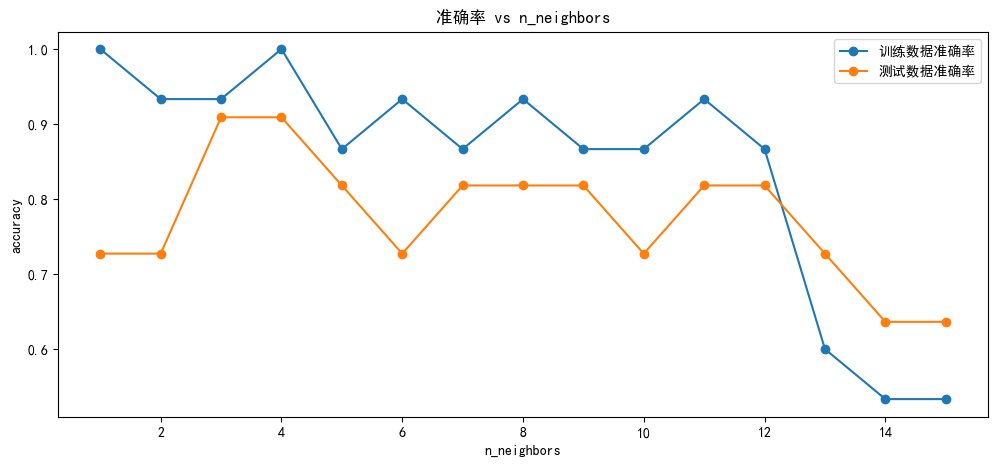

In [45]:
fig5=plt.figure(figsize=(12,5))
line_train =plt.plot(n,accuracy_train,marker='o')
line_test=plt.plot(n,accuracy_test,marker='o')
plt.legend((line_train[0] ,line_test[0]),('训练数据准确率','测试数据准确率'))
plt.title('准确率 vs n_neighbors')
plt.xlabel('n_neighbors')
plt.ylabel('accuracy')
plt.show()